In [18]:
import os
from datetime import datetime, timedelta

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

# ----------------------------
# CONFIG
# ----------------------------
folder = '/srv/seolab/srai/tropicalPacifiTemperatureBudget/WPWP_GLORYS_data/'

start_date = datetime(2018, 1, 1)
end_date   = datetime(2019, 6, 29)

# longitude window (degrees, likely 0–360 on GLORYS)
LON_MIN = 180.0
LON_MAX = 220.0

# latitude window (degrees)
LAT_MIN = -10.0
LAT_MAX = 10.0

# ----------------------------
# HELPERS
# ----------------------------
def date_list(d0, d1):
    n = (d1 - d0).days + 1
    return [d0 + timedelta(days=i) for i in range(n)]

def open_flux_path(d):
    return os.path.join(folder, f'GLORYS12v1_dailyAvg_trendWithFluxes_{d:%Y-%m-%d}.nc')

def open_var_path(d):
    return os.path.join(folder, f'GLORYS12v1_dailyAvg_{d:%Y-%m-%d}.nc')

# ----------------------------
# INITIAL METADATA READ (to get lat/lon & indices)
# ----------------------------
first_vars = xr.open_dataset(open_var_path(start_date))
lat = first_vars['latitude'].values
lon = first_vars['longitude'].values

# nearest latitude index to LAT_MIN
lat_idx_start = int(np.argmin(np.abs(lat - LAT_MIN)))
lat_idx_end = int(np.argmin(np.abs(lat - LAT_MAX)))

# longitude slice indices
lon_idx_start = int(np.argmin(np.abs(lon - LON_MIN)))
lon_idx_end   = int(np.argmin(np.abs(lon - LON_MAX)))

# depth index

depth_idx_start, depth_idx_end = 0, 3

# ensure start <= end (no wrap handling needed for 160E–220E on 0–360 grid)
if lon_idx_start > lon_idx_end:
    lon_idx_start, lon_idx_end = lon_idx_end, lon_idx_start


first_vars.close()

# ----------------------------
# GATHER DAILY SLICES
# ----------------------------
temps = []       # volume weighted average temp
advecs = []      # volume weighted average temp
dates = []       # for plotting / reference

for d in date_list(start_date, end_date):
    if d.day == 1:
        print(f'processing month {d:%Y-%m}')

    var_path = open_var_path(d)
    flux_path = open_flux_path(d)

    if not (os.path.exists(var_path) and os.path.exists(flux_path)):
        # skip missing days
        continue

    ds_vars  = xr.open_dataset(var_path)
    ds_flux  = xr.open_dataset(flux_path)

    try:
        # Select surface (depth=depthIndex), chosen latitude, lon slice, and first (only) time
        dVol = ds_flux['dVol'].isel(time=0, depth=slice(depth_idx_start, depth_idx_end+1), 
                                     latitude=slice(lat_idx_start, lat_idx_end +1),
                                     longitude=slice(lon_idx_start, lon_idx_end + 1)).transpose('depth', 'latitude', 'longitude').values
        totVol = np.nansum(dVol)
        T = ds_flux['trend_thetao'].isel(time=0, depth=slice(depth_idx_start, depth_idx_end+1), 
                                         latitude=slice(lat_idx_start, lat_idx_end +1),
                                         longitude=slice(lon_idx_start, lon_idx_end + 1)).transpose('depth', 'latitude', 'longitude').values * dVol/totVol
        ADV = ds_flux['thetao_flux_total'].isel(time=0, depth=slice(depth_idx_start, depth_idx_end+1), 
                                                latitude=slice(lat_idx_start, lat_idx_end +1),
                                                longitude=slice(lon_idx_start, lon_idx_end + 1)).transpose('depth', 'latitude', 'longitude').values * dVol/totVol

        temps.append(T)
        advecs.append(ADV)
        dates.append(d)
    finally:
        ds_vars.close()
        ds_flux.close()

# Convert lists to arrays
# Resulting shapes: (ndays, nx)
temp = np.asarray(temps)
advection = np.asarray(advecs)

if temp.size == 0:
    raise RuntimeError("No data gathered. Check file paths and date range.")


processing month 2018-01
processing month 2018-02
processing month 2018-03
processing month 2018-04
processing month 2018-05
processing month 2018-06
processing month 2018-07
processing month 2018-08
processing month 2018-09
processing month 2018-10
processing month 2018-11
processing month 2018-12
processing month 2019-01
processing month 2019-02
processing month 2019-03
processing month 2019-04
processing month 2019-05
processing month 2019-06


In [19]:
dVol.shape

(4, 241, 481)

In [20]:
temp.shape

(545, 4, 241, 481)

In [23]:
trend = np.nansum(temp, axis = (1,2,3))
adv_contribution = np.nansum(advection, axis=(1,2,3))

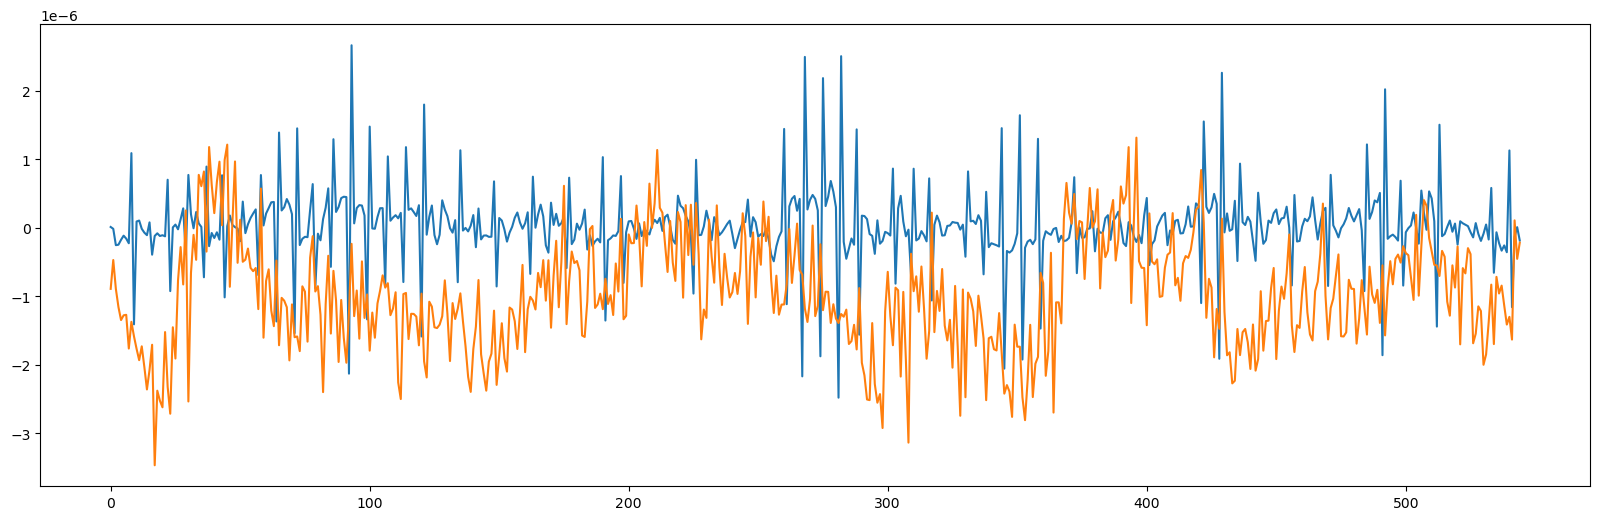

In [24]:
plt.figure(figsize=(20,6))
plt.plot(trend)
plt.plot(adv_contribution)